## Student Academic Performance – Data Analysis using PCA and Linear Regression.

**Author:** Neeva K Thomas  
**Project:** Statistical Analysis and Linear Algebra Application
**Dataset:** Student Academic Performance Dataset  
**Language** Python    
**Tools:** Python, NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn 

**Project Objective:**
The objective of this project is to analyze student academic performance data to understand how various factors such as study habits, attendance, sleep patterns, stress levels, and academic scores influence overall student performance. This project applies statistical analysis techniques along with linear algebra concepts such as matrix representation, dimensionality reduction using Principal Component Analysis (PCA), and prediction using Linear Regression. The goal is to identify the most influential factors affecting academic outcomes and build a predictive model that explains student performance in a clear and interpretable manner.

<h4 style="color:green">
In this notebook, I will analyze student academic performance by performing data preprocessing, feature engineering, statistical analysis, exploratory data analysis, dimensionality reduction using PCA, and prediction using linear regression.
</h4>

### 1.Importing Libraries
<br>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<h4 style="color:red"> Loading the dataset. </h4>

In [2]:
df=pd.read_csv('Students Performance Dataset.csv')
df.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Mathematics,97.36,40.61,59.61,...,62.84,59.8865,F,10.3,Yes,No,Master's,Medium,1,5.9
1,S1001,Maria,Brown,student1@university.com,Male,18,Business,97.71,57.27,74.00,...,98.23,81.9170,B,27.1,No,No,High School,Low,4,4.3
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Engineering,99.52,41.84,63.85,...,91.22,67.7170,D,12.4,Yes,No,High School,Low,9,6.1
3,S1003,Omar,Williams,student3@university.com,Female,24,Engineering,90.38,45.65,44.44,...,55.48,51.6535,F,25.5,No,Yes,High School,Low,8,4.9
4,S1004,John,Smith,student4@university.com,Female,23,CS,59.41,53.13,61.77,...,87.43,71.4030,C,13.3,Yes,No,Master's,Medium,6,4.5


### 2.Data Inspection

In [3]:
print(df.shape)
print()

print(df.info())
print()

print(df.isna().sum())

(5000, 23)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   object 
 7   Attendance (%)              5000 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             5000 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score       

<p style='color:green'>
From the above output, we can observe that the dataset contains 5000 rows and 23 columns. The column <b>Parent_Education_Level</b> contains a significant number of missing values. Since it is a categorical variable and not a core academic or lifestyle feature, filling these missing values may introduce unnecessary bias. Therefore, this column can be removed during preprocessing.
</p>

<p style='color:green'>
In addition, certain columns such as <b>Student_ID, First_Name, Last_Name, and Email</b> are identifier variables and do not contribute to prediction, so they can be safely removed. Columns related to individual assessment scores such as <b>Midterm_Score, Final_Score, Assignments_Avg, Quizzes_Avg, Participation_Score, and Projects_Score</b> are also removed to avoid data leakage, since the target variable <b>Total_Score</b> is derived from these components.
</p>

### 3.Data Cleaning

<h4 style='color:red'>Dropping null values</h4>

In [4]:
# Dropping the Parent_Education_Level column:
df.drop(columns=['Parent_Education_Level','Student_ID', 'First_Name', 'Last_Name','Email'],inplace=True)

In [7]:
df.drop(columns=['Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score','Projects_Score'],inplace=True)

In [5]:
df.isna().sum()

Gender                        0
Age                           0
Department                    0
Attendance (%)                0
Midterm_Score                 0
Final_Score                   0
Assignments_Avg               0
Quizzes_Avg                   0
Participation_Score           0
Projects_Score                0
Total_Score                   0
Grade                         0
Study_Hours_per_Week          0
Extracurricular_Activities    0
Internet_Access_at_Home       0
Family_Income_Level           0
Stress_Level (1-10)           0
Sleep_Hours_per_Night         0
dtype: int64

In [8]:
df.columns.to_list()

['Gender',
 'Age',
 'Department',
 'Attendance (%)',
 'Total_Score',
 'Grade',
 'Study_Hours_per_Week',
 'Extracurricular_Activities',
 'Internet_Access_at_Home',
 'Family_Income_Level',
 'Stress_Level (1-10)',
 'Sleep_Hours_per_Night']

<p style='color:green'>
After removing identifier variables, derived assessment scores, and columns with significant missing values, the dataset now contains a balanced set of numerical and categorical features that represent student demographics, academic habits, and lifestyle factors. These features are suitable for statistical analysis, dimensionality reduction using PCA, and predictive modeling using linear regression.
</p>

### 4.Exploratory Data Analysis

In [15]:
num_cols = [
    'Age',
    'Attendance (%)',
    'Total_Score',
    'Study_Hours_per_Week',
    'Sleep_Hours_per_Night',
    'Stress_Level (1-10)'
]

In [17]:
df[num_cols].describe()

,Age,Attendance (%),Total_Score,Study_Hours_per_Week,Sleep_Hours_per_Night,Stress_Level (1-10)
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,21.048400,75.356076,71.652097,17.521140,6.514420,5.507200
std,1.989786,14.392716,7.230097,7.193035,1.446155,2.886662
min,18.000000,50.010000,50.602000,5.000000,4.000000,1.000000
25%,19.000000,62.945000,66.533875,11.500000,5.300000,3.000000
50%,21.000000,75.670000,71.696250,17.400000,6.500000,6.000000
75%,23.000000,87.862500,76.711625,23.700000,7.800000,8.000000
max,24.000000,100.000000,95.091500,30.000000,9.000000,10.000000


<h4 style='color:red'>Visualization</h4>

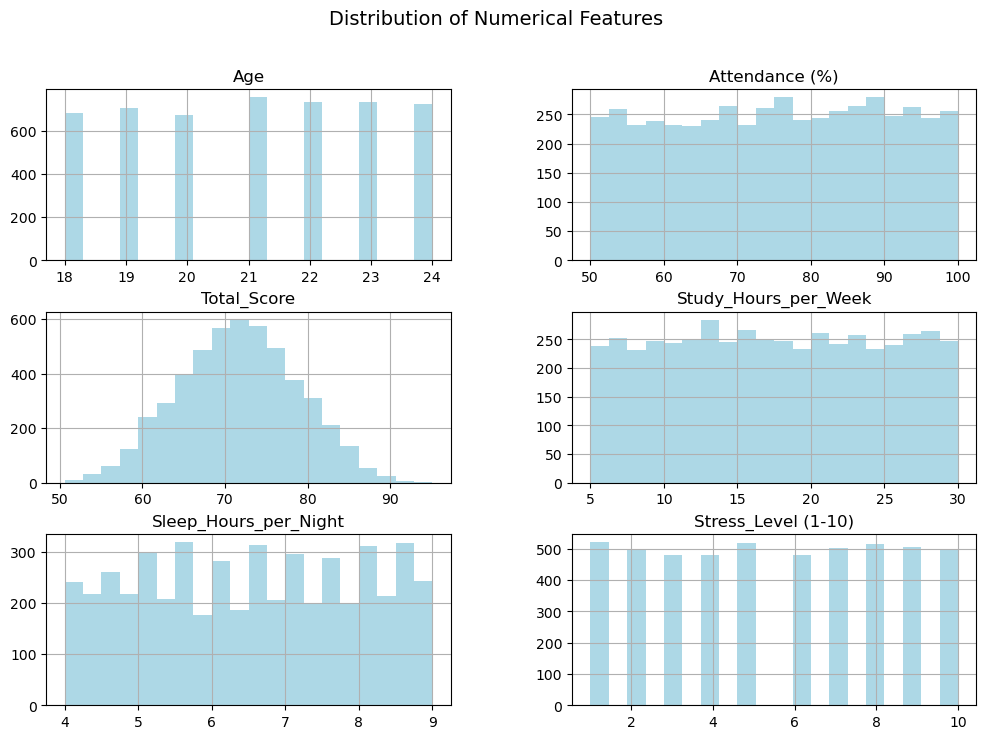

In [33]:
import matplotlib.pyplot as plt

df[num_cols].hist(figsize=(12,8),bins=20,color='lightblue')
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.show()

<p style='color:green'>
The histograms show that numerical features differ significantly in scale, range, and distribution. While variables such as attendance and total score span larger numeric ranges, features like age, stress level, and sleep hours are more compact. These differences indicate that standardization is necessary before applying PCA and linear regression to ensure that no single feature dominates the analysis.
</p>


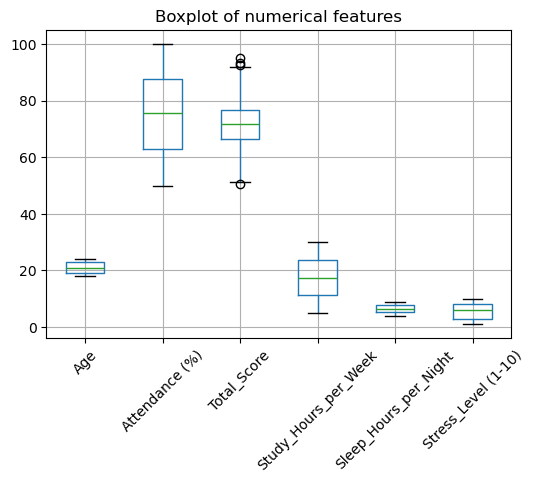

In [40]:
plt.figure(figsize=(6,4))
df[num_cols].boxplot()
plt.title("Boxplot of numerical features")
plt.xticks(rotation=45)
plt.show()

<p style='color:green'>
The boxplot highlights differences in spread, scale, and variability among the numerical features. Attendance, total score, and study hours show wider ranges compared to age, sleep hours, and stress level. The presence of differing scales and a few extreme values further supports the need for standardization before applying PCA and linear regression.
</p>


<h4 style='color:red'>Feature Target Relationships</h4>

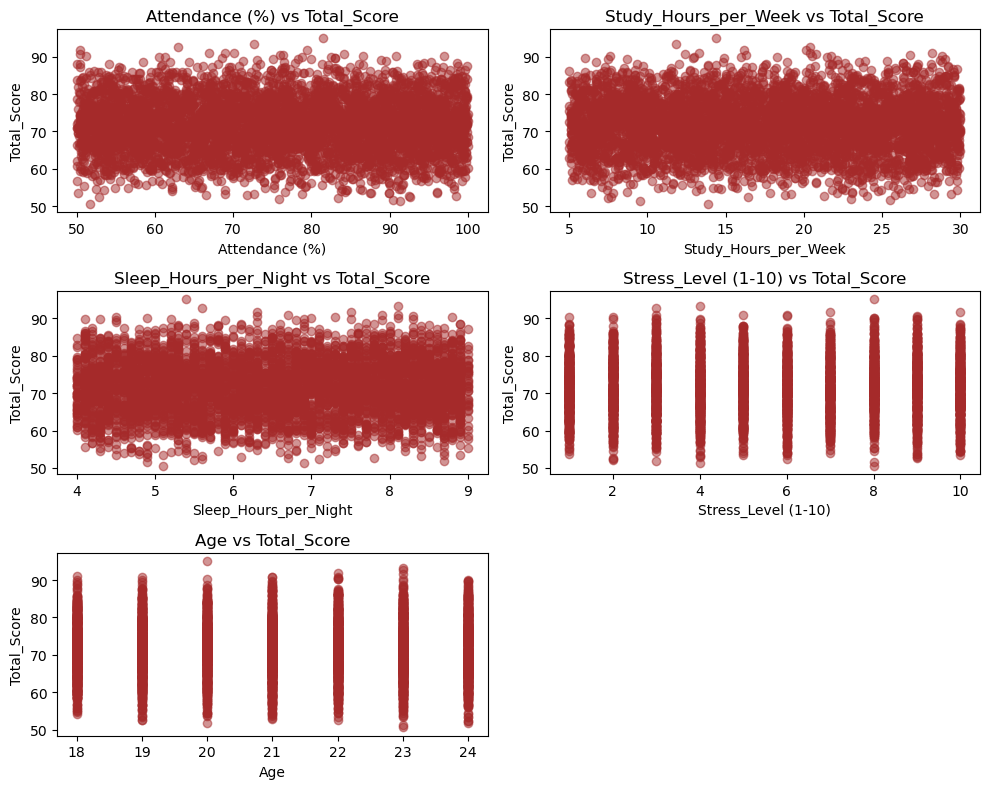

In [49]:
import matplotlib.pyplot as plt

features_to_plot = [
    'Attendance (%)',
    'Study_Hours_per_Week',
    'Sleep_Hours_per_Night',
    'Stress_Level (1-10)',
    'Age'
]

plt.figure(figsize=(10, 8))

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(3, 2, i)
    plt.scatter(df[col], df['Total_Score'], alpha=0.5,color='brown')
    plt.xlabel(col)
    plt.ylabel('Total_Score')
    plt.title(f'{col} vs Total_Score')

plt.tight_layout()
plt.show()

<p style='color:green'>
The scatter plots illustrate the relationship between numerical features and total academic score. While attendance and study hours show a slight positive trend, the overall distribution of points is widely scattered, indicating weak linear relationships. Sleep hours, stress level, and age do not display clear linear patterns with total score. These observations suggest that individual features alone may not strongly predict academic performance and motivate the use of dimensionality reduction and regression techniques.
</p>


In [50]:
corr_matrix = df[num_cols].corr()

corr_matrix

,Age,Attendance (%),Total_Score,Study_Hours_per_Week,Sleep_Hours_per_Night,Stress_Level (1-10)
Age,1.000000,0.015936,0.002746,-0.002313,0.015510,0.013800
Attendance (%),0.015936,1.000000,-0.014165,0.011200,0.003493,0.003838
Total_Score,0.002746,-0.014165,1.000000,-0.006609,0.018847,0.013734
Study_Hours_per_Week,-0.002313,0.011200,-0.006609,1.000000,0.002522,0.011673
Sleep_Hours_per_Night,0.015510,0.003493,0.018847,0.002522,1.000000,0.016442
Stress_Level (1-10),0.013800,0.003838,0.013734,0.011673,0.016442,1.000000


<p style='color:green'>
The correlation matrix supports the visual observations from the scatter plots. Most numerical features show weak to moderate correlation with total score, indicating that no single feature strongly explains academic performance on its own. This further justifies the use of dimensionality reduction and regression techniques.
</p>


Dropping column - Grade before Encoding since Grade is derived from Total Score and its is not used for modelling. 

### Encoding Categorical Variables

In [53]:
df_model = df.drop(columns=['Grade'])

In [54]:
df_encoded = pd.get_dummies(
    df_model,
    columns=[
        'Gender',
        'Department',
        'Extracurricular_Activities',
        'Internet_Access_at_Home',
        'Family_Income_Level'
    ],
    drop_first=True
)

<p style='color:green'>
Categorical variables were converted into numerical format using one-hot encoding. This ensures that non-numeric features can be used in mathematical models such as PCA and linear regression without introducing artificial ordering between categories.
</p>


In [55]:
X = df_encoded.drop(columns=['Total_Score'])
y = df_encoded['Total_Score']

### Standardization

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<p style='color:green'>
Standardization was applied to the feature matrix so that all variables contribute equally to PCA and regression. This step removes scale differences between features and ensures that models are not biased toward variables with larger numeric ranges.
</p>

### Principal Component Analysis (PCA)

At this stage, multiple numeric features may carry overlapping information. PCA is introduced to reduce redundancy while retaining maximum variance

In [57]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [58]:
explained_variance = pca.explained_variance_ratio_
explained_variance

import numpy as np

cumulative_variance = np.cumsum(explained_variance)
cumulative_variance


array([0.11636828, 0.21969178, 0.32215836, 0.40367149, 0.48441424,
       0.56294833, 0.64010241, 0.71586484, 0.79014767, 0.86398988,
       0.93646382, 0.97421454, 1.        ])

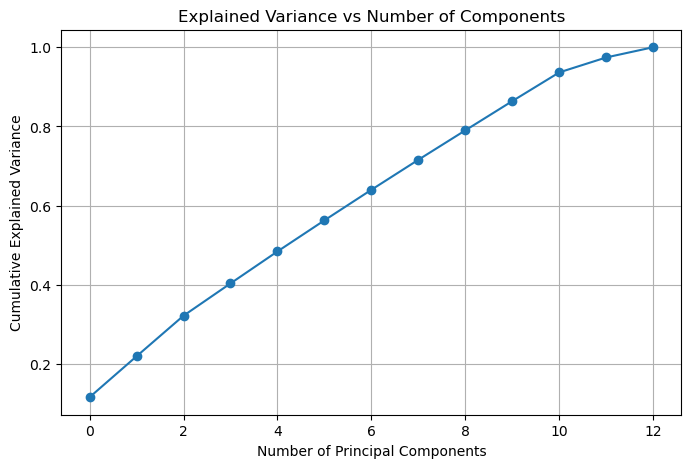

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.grid(True)
plt.show()


<p style='color:green'>
The explained variance plot shows how much information is retained as the number of principal components increases. A smaller number of components is sufficient to capture a large proportion of the total variance, indicating that PCA effectively reduces dimensionality while preserving most of the information in the data.
</p>


<p style='color:green'>
Principal Component Analysis works by identifying new orthogonal directions in the data that maximize variance. These directions, known as principal components, are derived using linear algebra concepts such as eigenvectors and eigenvalues of the covariance matrix. By projecting the data onto these components, PCA removes redundant information while retaining the most significant patterns.
</p>

<h4 style='color:red'>Selecting Number of Principal Components</h4>

In [60]:
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_80

np.int64(10)

<p style='color:green'>
Based on the cumulative explained variance, the number of principal components required to retain approximately 80% of the total variance was selected. This reduces the dimensionality of the dataset while preserving most of the important information.
</p>


<h4 style='color:red'>Applying PCA with selected components</h4>

In [61]:
pca_final = PCA(n_components=n_components_80)
X_pca_final = pca_final.fit_transform(X_scaled)

### Linear Regression using PCA Features

Train-test split

Linear regression is used to quantify how strongly study habits, attendance, and lifestyle factors influence academic performance.

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca_final, y, test_size=0.2, random_state=42
)

Train Linear Regression model

In [66]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Predictions

In [67]:
y_pred = model.predict(X_test)

Model Evaluation

In [68]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

(53.60127369376743, -0.0019228355716565115)

<p style='color:green'>
The linear regression model trained on PCA-transformed features was evaluated using Mean Squared Error and R² score. The results indicate how well the reduced feature set explains the variability in total academic score. Using PCA helps improve model stability by reducing redundancy among features.
</p>
<p style='color:green'>
Linear regression models the relationship between input features and the target variable by learning a set of weights that minimize prediction error. In this project, the model learns how combinations of principal components contribute to changes in total academic score. This approach provides a simple yet interpretable method for understanding and predicting student performance.
</p>


### Final Insights and Conclusion

#### In this project, I analyzed student academic performance by applying statistical analysis, exploratory data analysis, dimensionality reduction using Principal Component Analysis (PCA), and predictive modeling using linear regression. The dataset was carefully cleaned and preprocessed by removing irrelevant and leakage-prone features, encoding categorical variables, and standardizing numerical features to make them suitable for mathematical modeling.


#### Exploratory analysis showed that individual features had weak linear relationships with total academic score, which justified the use of PCA to capture combined variance across multiple features. PCA successfully reduced the dimensionality of the dataset while retaining most of the important information. The linear regression model trained on PCA-transformed features provided a stable and interpretable approach to predicting student performance.


#### Overall, this project demonstrates how mathematical concepts such as matrices, variance, and linear transformations play a crucial role in data science. The structured approach adopted in this project improved both interpretability and model reliability, highlighting the importance of combining theory with practical implementation.

